## Import Libraries

In [1]:
import numpy as np
from qiskit import QuantumCircuit,transpile, ClassicalRegister, QuantumRegister
from qiskit.quantum_info import Kraus, SuperOp
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.quantum_info import Statevector,DensityMatrix,state_fidelity,partial_trace, Operator
from matplotlib import pyplot as plt
from functools import reduce
from scipy.linalg import expm
import pandas as pd
from qiskit_aer import AerSimulator
import qiskit.circuit.classical as qiskit_classical
from qiskit.quantum_info import SparsePauliOp
from IPython.display import display
from qiskit.providers.fake_provider import GenericBackendV2
#from qiskit.opflow import I, Z, StateFn, PauliExpectation, CircuitSampler
#from qiskit import Aer, execute, transpile
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
import os
from dotenv import load_dotenv
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2

# Import from Qiskit Aer noise module
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)




Hamiltonian:

$H=-h(X_1+X_2)-J Z_1 Z_2$

Trotter formula:

$e^{-iH t}=(e^{i h X_1 \Delta t}e^{i h X_2 \Delta t}e^{i J Z_1 Z_2 \Delta t})^{N_{\text{Trot}}},$

where $\Delta t=t/N_{\text{Trot}}$.

### Run Test on Fake Provider

In [2]:
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke, FakeBrisbane
from qiskit.visualization import plot_error_map

#Get Transpiled Circuit for IBM--------------------------------
service = QiskitRuntimeService()
# backend = GenericBackendV2(num_qubits=d*4)
# backend = FakeBrisbane()
backend = FakeSherbrooke()
# plot_error_map(backend)

# 1. Transpile with layout
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)


/tmp/ipykernel_20997/3007228027.py:5: DeprecationWarning: The "ibm_quantum" channel option is deprecated and will be sunset on 1 July. After this date, ibm_cloud will be the only valid channel. For information on migrating to the new IBM Quantum Platform on the "ibm_cloud" channel, review the migration guide https://quantum.cloud.ibm.com/docs/migration-guides/classic-iqp-to-cloud-iqp .
  service = QiskitRuntimeService()


Test Circuit

In [3]:
class ising_class:
    def __init__(self, d, steps, t, J, h):
        self.d = d
        self.steps = steps
        self.t = t
        self.J = J
        self.h = h

    def get_trotterized_ising_circuit(self):
        
        """
        Returns a QuantumCircuit implementing a trotterized Ising evolution for d qubits.

        H = - J * sum(Z_i Z_{i+1}) - h * sum(X_i)
        U = exp(-i H t) 
        """
        t = self.t
        steps = self.steps
        d = self.d
        J = self.J
        h = self.h

        dt = t / steps
        qc = QuantumCircuit(d)

        for _ in range(steps):
            # Apply ZZ interactions (Z_i Z_{i+1})
            for i in range(d - 1):
                qc.cx(i, i + 1)
                qc.rz(-2 * J * dt, i + 1)
                qc.cx(i, i + 1)

            # Apply transverse field X terms (X_i)
            for i in range(d):
                qc.rx(-2 * h * dt, i)

        return qc

    def apply_ising_to_registers(self, qc,start):
        """
        Apply trotterized Ising circuit to registers q1, q2, q3 in a 4d-sized register circuit.
        """
        d = self.d
        ising = self.get_trotterized_ising_circuit()

        # Convert to instruction and append to registers q1, q2, q3
        ising_inst = ising.to_instruction()
        for reg in [1, 2, 3]:
            qc.append(ising_inst, [(reg-1) * d + i + start for i in range(d)])

        return qc

    def get_trotterized_ising_statevector(self):
        """
        Returns the statevector from the trotterized Ising evolution of d qubits.
        """
        qc = self.get_trotterized_ising_circuit()
        qc.save_statevector()

        simulator = AerSimulator()
        result = simulator.run(transpile(qc, simulator)).result()
        return result.get_statevector()

def get_QPA_circuit(d, N, ising_circuit,single_control=False,reduced_if=False):
    #FUNCTION TO GET QPA CIRCUIT
    if single_control:
       ncontrols=1
       get_control = lambda x: 0
    else:
       ncontrols=d
       get_control = lambda x: x
    cr_q0 = ClassicalRegister(ncontrols,name='control')
    qr_all = QuantumRegister(3*d+ncontrols)

    # Initialize quantum circuit with classical registers
    qcSWAP = QuantumCircuit(qr_all, cr_q0)  # Extra qubit and classical bit for parity check
    
    qc = ising_circuit.apply_ising_to_registers(qcSWAP,start=ncontrols) #Apply trotterized Ising circuit, 1)
    
    def recursive(N,qc):
      for k in range(ncontrols):
        qc.reset(k)
      qc.h(0)#q0_firstqbit = |0>+|1>/sqrt2
      for k in range(ncontrols-1):
        qc.cx(0,1+k)#q0 = |0000...> + |1111...>/sqrt2
      # Apply the first CSWAP gate controlled by q0, targeting q1 and q2
      for k in range(d):
        qc.cswap(get_control(k), k+ncontrols, k+d+ncontrols)#|+>_k x SYM12_k + |->_k x AntiSYM12_k /norm

      # Apply the second Hadamard gate to q0
      for k in range(ncontrols):
        qc.h(k) #|0> x SYM12 + |1> x AntiSYM12 /norm
      # Measure qubits 0 to d-1 into classical bits 0 to d-1

      for i in range(ncontrols): #Measure the control registers and find z
          qc.measure(i, cr_q0[i])
          if i==0:
            parity_control = qiskit_classical.expr.lift(cr_q0[i])
          else:
            parity_control = qiskit_classical.expr.bit_xor(parity_control, cr_q0[i])

      with qc.if_test(parity_control) as _else:
        #--------Z=1
        pass
      with _else:
        #---------Z = 0
        # qc.x(d+1) # Good test to make sure it's working
        for k in range(d):
          qc.swap(k+d+ncontrols, k+2*d+ncontrols) #Swap q2 with q3
        if not reduced_if:
          if N!=1:
            qc = recursive(N-1,qc) #Do it again unless it was the final iteration of the SWAPNET
            
      if reduced_if:
         if N!=1:
          qc = recursive(N-1,qc)
      return qc
    
    if N!=0:
      qc = recursive(N,qcSWAP)
    else:
      qc = qcSWAP
    # Gets Measure register q3 and save in the classical register
    # for i in range(d):
    #     qc.measure(3*d+i, cr_q0[i]) 
    return qc

def run_qc_and_return_state(qc):

    # Select Aer Simulator backend
    simulator = AerSimulator()

    def execute_circuit_on_state(qc):
        """ Executes a circuit on the AerSimulator and returns the state result. """
        qc_transpiled = transpile(qc, simulator)
        result = simulator.run(qc_transpiled).result()
        return result.get_statevector(qc_transpiled)

    qc.save_statevector()
    state = execute_circuit_on_state(qc)

    return state

def estimate_qc_and_return_distribution(qc,observables,estimator = AerEstimator()):
    pass_manager = generate_preset_pass_manager(3, AerSimulator())
    isa_circuit = pass_manager.run(qc)
    qc_transpiled = transpile(isa_circuit)

    result = estimator.run([(qc_transpiled,observables,None)]).result()
    exp_val = result[0].data.evs
    return exp_val
    # pub_result = result[0]
    # counts = pub_result.data.control.get_counts()
    # return counts





In [4]:
d= 3 
single_control = True
t=10.0
J=1
h=1
steps = 3

In [44]:
ising = ising_class(d, steps, t, J, h)
trotterized_state = ising.get_trotterized_ising_statevector()
N_qpa = 1
QPA_0 = get_QPA_circuit(d, N_qpa, ising,single_control=single_control)
def get_projector(single_control= False):
    fidelity_operator = SparsePauliOp.from_operator(trotterized_state.to_operator())
    identity_op = SparsePauliOp(["I" * (d)])
    if single_control:
        control_identity = SparsePauliOp(["I"])
    else:
        control_identity = identity_op
    full_space_fidelity_operator = fidelity_operator.tensor(identity_op).tensor(identity_op).tensor(control_identity)
    # full_space_fidelity_operator = identity_op.tensor(fidelity_operator).tensor(identity_op).tensor(control_identity)
    return full_space_fidelity_operator


full_space_fidelity_operator = get_projector(single_control)
qc_transpiled_0 = transpile(QPA_0, backend=backend, optimization_level=1)
layout_0 = qc_transpiled_0.layout
observable_0 = full_space_fidelity_operator.apply_layout(layout_0)
estimator = EstimatorV2(mode=backend)
estimator.options.default_shots = 1024*10
# job0 = estimator.run([(qc_transpiled_0, observable_0, None)]).result()
job0 = estimator.run([(qc_transpiled_0, observable_0, None)]).result()

fidelity0 = job0[0].data.evs
print(fidelity0)



0.5708080865338137


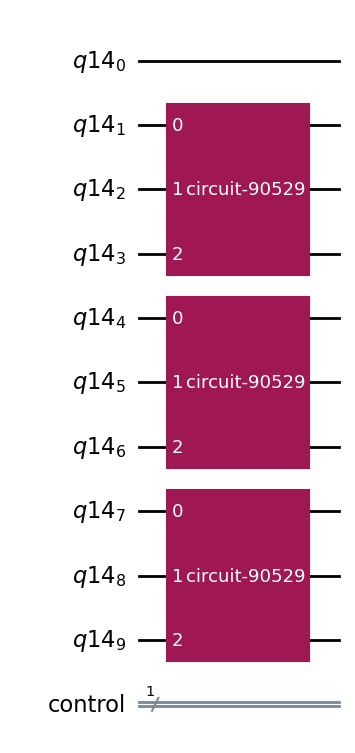

None


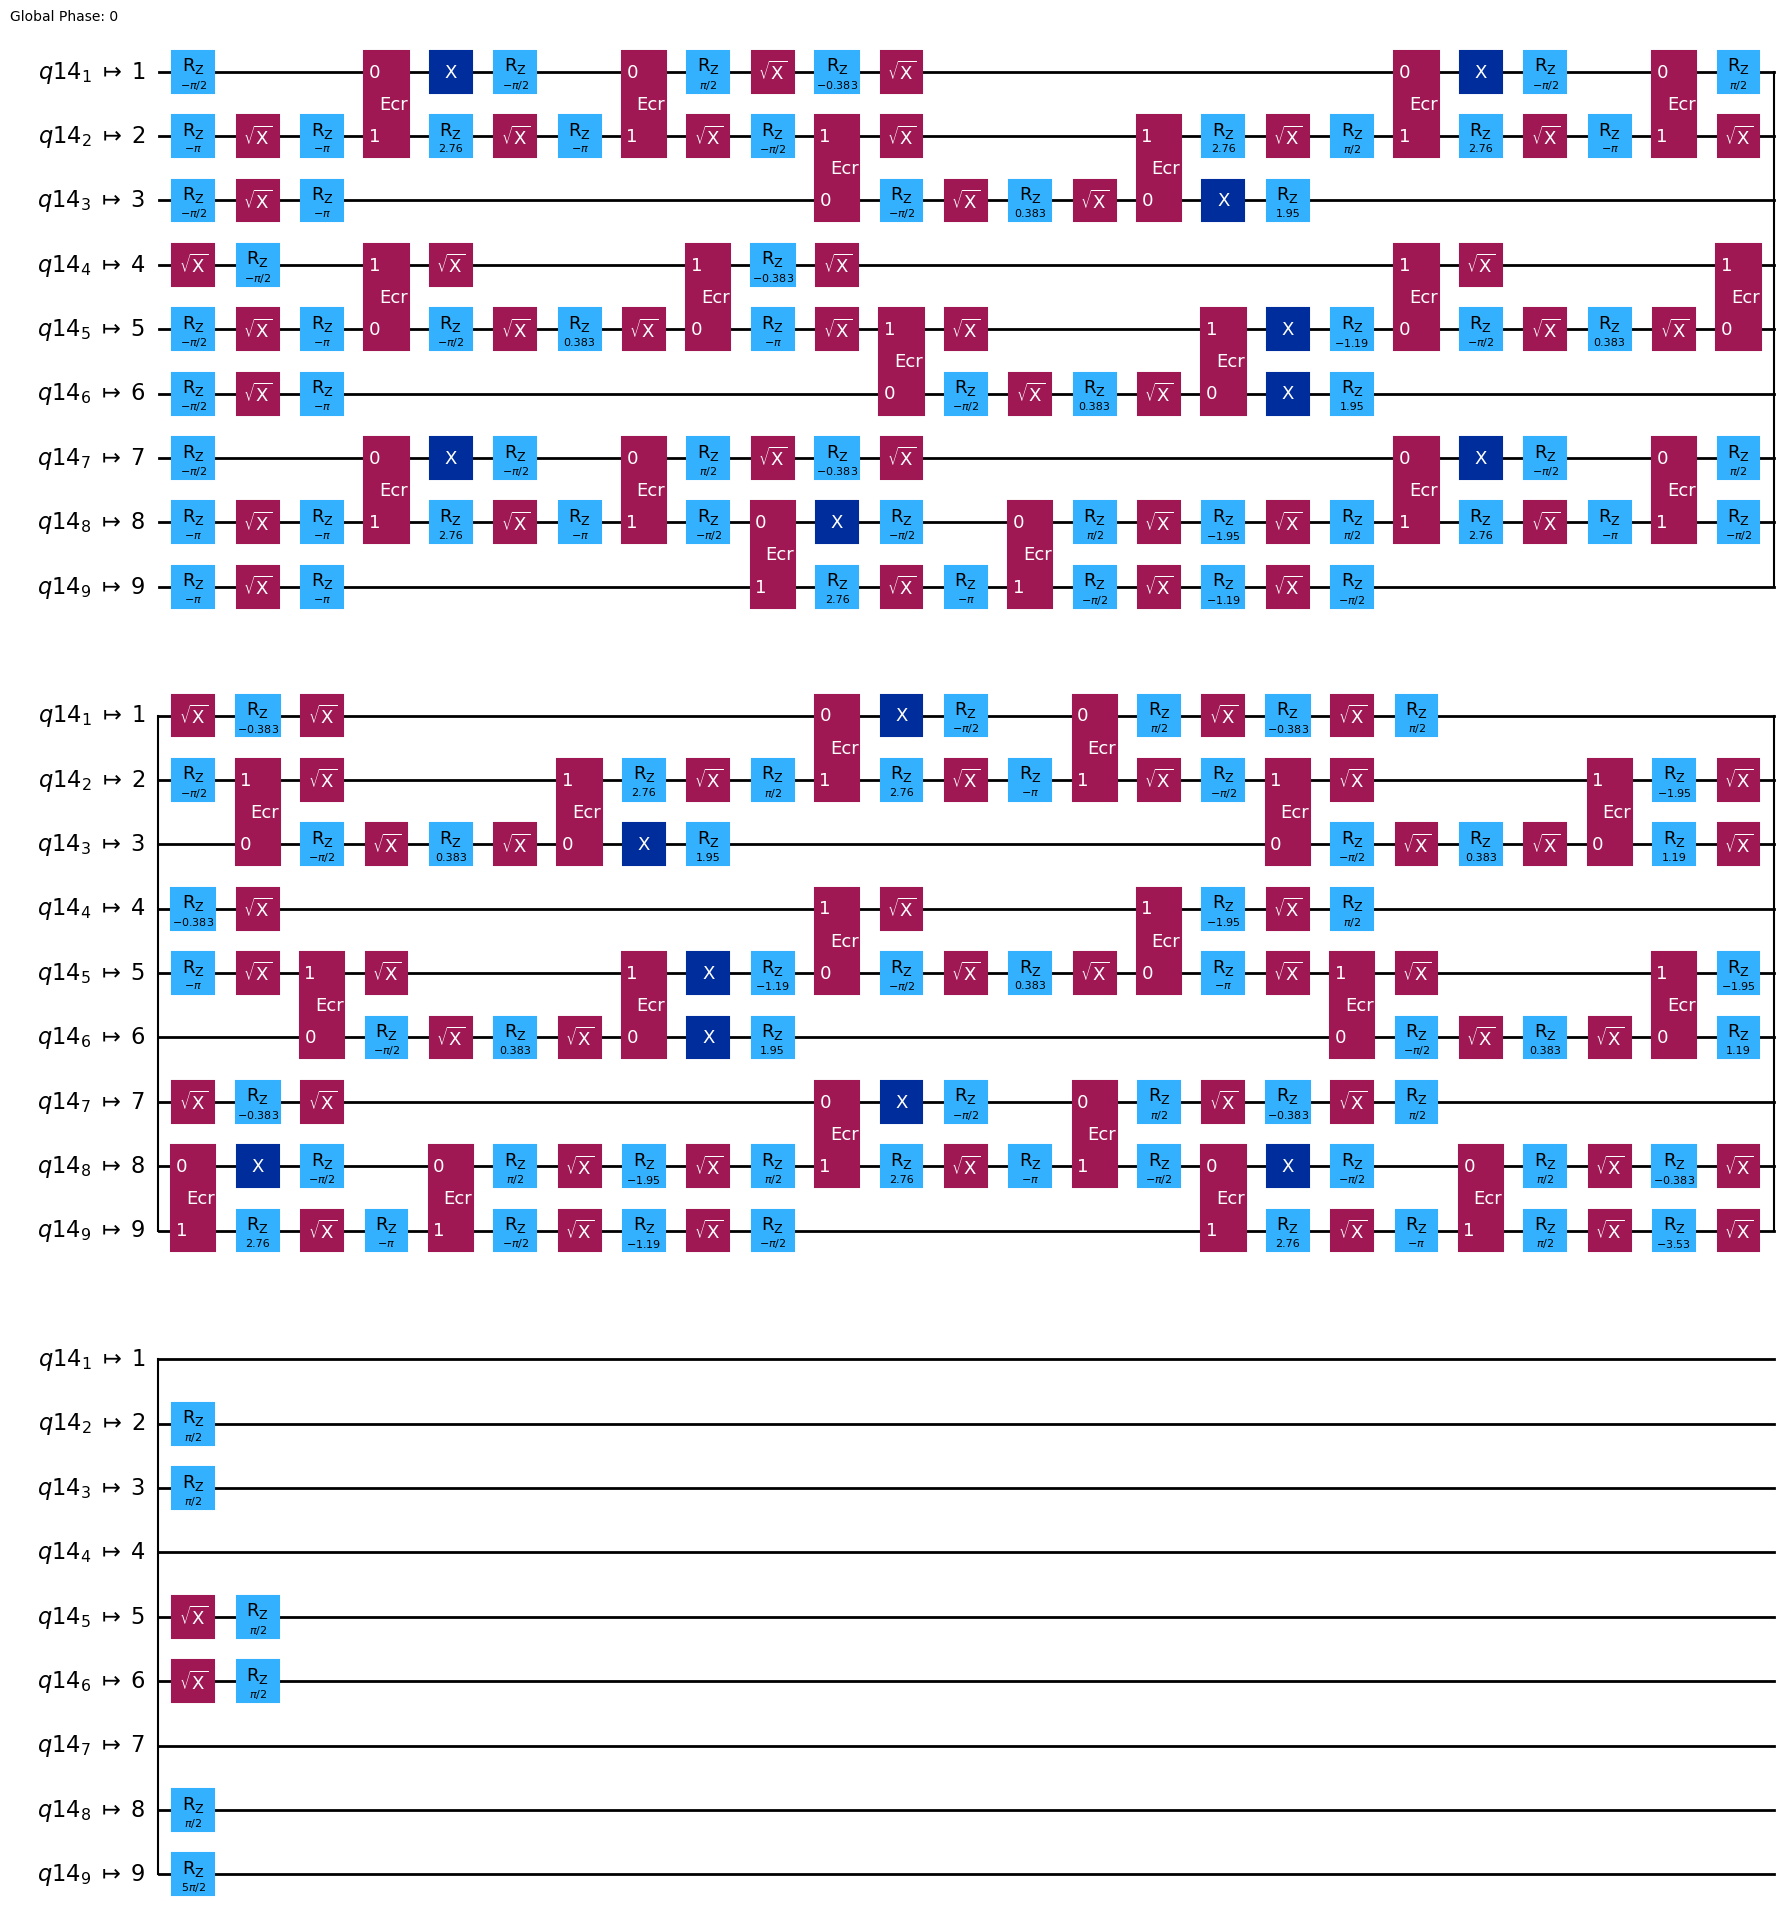

None
0.13079179949846628


In [19]:
ising = ising_class(d, steps, t, J, h)
trotterized_state = ising.get_trotterized_ising_statevector()
N_qpa = 0
QPA_0 = get_QPA_circuit(d, N_qpa, ising,single_control=single_control)
def get_projector(single_control= False):
    fidelity_operator = SparsePauliOp.from_operator(trotterized_state.to_operator())
    identity_op = SparsePauliOp(["I" * (d)])
    if single_control:
        control_identity = SparsePauliOp(["I"])
    else:
        control_identity = identity_op
    full_space_fidelity_operator = fidelity_operator.tensor(identity_op).tensor(identity_op).tensor(control_identity)
    # full_space_fidelity_operator = control_identity.tensor(identity_op).tensor(identity_op).tensor(fidelity_operator)
    
    # full_space_fidelity_operator = identity_op.tensor(fidelity_operator).tensor(identity_op).tensor(control_identity)
    return full_space_fidelity_operator


full_space_fidelity_operator = get_projector(single_control)
backend = FakeSherbrooke()
qc_transpiled_0 = transpile(QPA_0, backend=backend, optimization_level=1)
layout_0 = qc_transpiled_0.layout
observable_0 = full_space_fidelity_operator.apply_layout(layout_0)

# backend=AerSimulator()
# qc_transpiled_0 = transpile(qc_transpiled_0, backend=backend, optimization_level=0)
# layout_0 = qc_transpiled_0.layout
# observable_0 = observable_0.apply_layout(layout_0)



estimator = EstimatorV2(mode=backend)
print(display(QPA_0.draw('mpl')))
print(display(qc_transpiled_0.draw('mpl')))
estimator.options.default_shots = 1024*10
# job0 = estimator.run([(qc_transpiled_0, observable_0, None)]).result()
job0 = estimator.run([(qc_transpiled_0, observable_0, None)]).result()

fidelity0 = job0[0].data.evs
print(fidelity0)



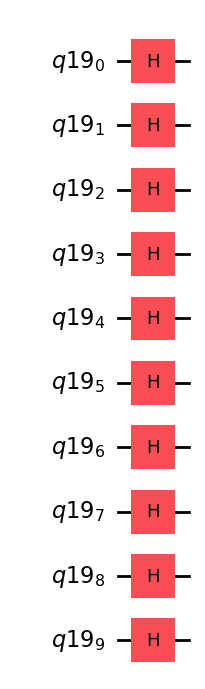

Statevector([0.03125+0.j, 0.03125+0.j, 0.03125+0.j, ..., 0.03125+0.j,
             0.03125+0.j, 0.03125+0.j],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2))
Operator([[0.00097656+0.j, 0.00097656+0.j, 0.00097656+0.j, ...,
           0.00097656+0.j, 0.00097656+0.j, 0.00097656+0.j],
          [0.00097656+0.j, 0.00097656+0.j, 0.00097656+0.j, ...,
           0.00097656+0.j, 0.00097656+0.j, 0.00097656+0.j],
          [0.00097656+0.j, 0.00097656+0.j, 0.00097656+0.j, ...,
           0.00097656+0.j, 0.00097656+0.j, 0.00097656+0.j],
          ...,
          [0.00097656+0.j, 0.00097656+0.j, 0.00097656+0.j, ...,
           0.00097656+0.j, 0.00097656+0.j, 0.00097656+0.j],
          [0.00097656+0.j, 0.00097656+0.j, 0.00097656+0.j, ...,
           0.00097656+0.j, 0.00097656+0.j, 0.00097656+0.j],
          [0.00097656+0.j, 0.00097656+0.j, 0.00097656+0.j, ...,
           0.00097656+0.j, 0.00097656+0.j, 0.00097656+0.j]],
         input_dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2), output_dims=(2, 2, 2, 2, 2, 2

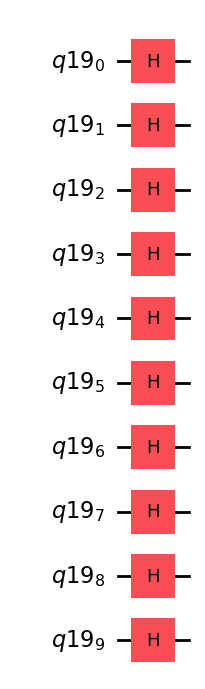

1.0


In [24]:
from qiskit_ibm_runtime.fake_provider import (
    FakeNairobiV2, FakeJakartaV2, FakeKolkataV2, FakeGuadalupeV2, FakeTorontoV2,
    FakeMontrealV2, FakeManilaV2, FakeLagosV2,FakeSherbrooke,FakeBrisbane
)
single_control = True
# backend = FakeSherbrooke()
# backend = FakeBrisbane()
backend=AerSimulator()
# ising = ising_class(d, steps, t, J, h)
# trotterized_state = ising.get_trotterized_ising_statevector()
if single_control:
       ncontrols=1
       get_control = lambda x: 0
else:
       ncontrols=d
       get_control = lambda x: x
# cr_q0 = ClassicalRegister(ncontrols,name='control')
qr_all = QuantumRegister(3*d+ncontrols)

# Initialize quantum circuit with classical registers
# qcSWAP = QuantumCircuit(qr_all, cr_q0)  # Extra qubit and classical bit for parity check
qcSWAP = QuantumCircuit(qr_all)  # Extra qubit and classical bit for parity check

qcSWAP.h(0)
for reg in range(3):
    for i in range(d):
        qcSWAP.h(1+d*reg+i)
display(qcSWAP.draw('mpl'))
def get_projector(single_control= False):
    qc = qcSWAP.copy()
    qc.save_statevector()

    simulator = AerSimulator()
    result = simulator.run(transpile(qc, simulator)).result()
    state = result.get_statevector()
    print(state)
    print(state.to_operator())
    print(SparsePauliOp.from_operator(state.to_operator()))
    
    identity_op = SparsePauliOp(["I" * (d)])
    if single_control:
        control_identity = SparsePauliOp(["I"])
    else:
        control_identity = identity_op
    return SparsePauliOp.from_operator(state.to_operator())
#     return identity_op.tensor(identity_op).tensor(identity_op).tensor(control_identity)
    


full_space_fidelity_operator = get_projector(single_control)
print('Operator:', full_space_fidelity_operator)
qc_transpiled_0 = transpile(qcSWAP, backend=backend, optimization_level=1)
display(qc_transpiled_0.draw('mpl'))
layout_0 = qc_transpiled_0.layout
observable_0 = full_space_fidelity_operator.apply_layout(layout_0)
estimator = EstimatorV2(mode=backend)
estimator.options.default_shots = 1024
# job0 = estimator.run([(qc_transpiled_0, observable_0, None)]).result()
job0 = estimator.run([(qc_transpiled_0, observable_0, None)]).result()

fidelity0 = job0[0].data.evs
print(fidelity0)



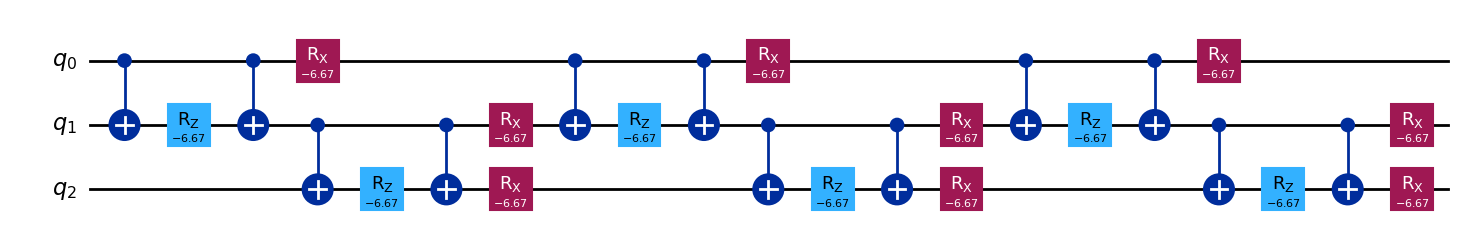

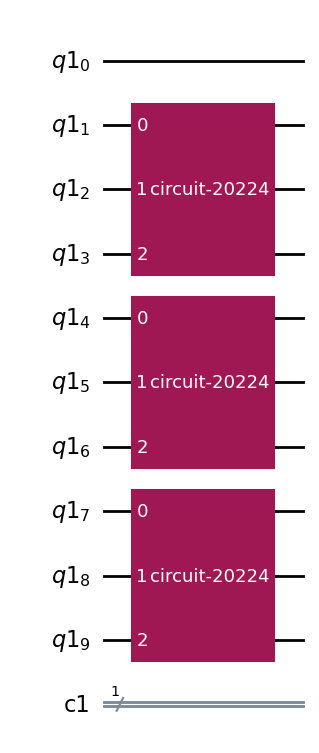

<IPython.core.display.Latex object>

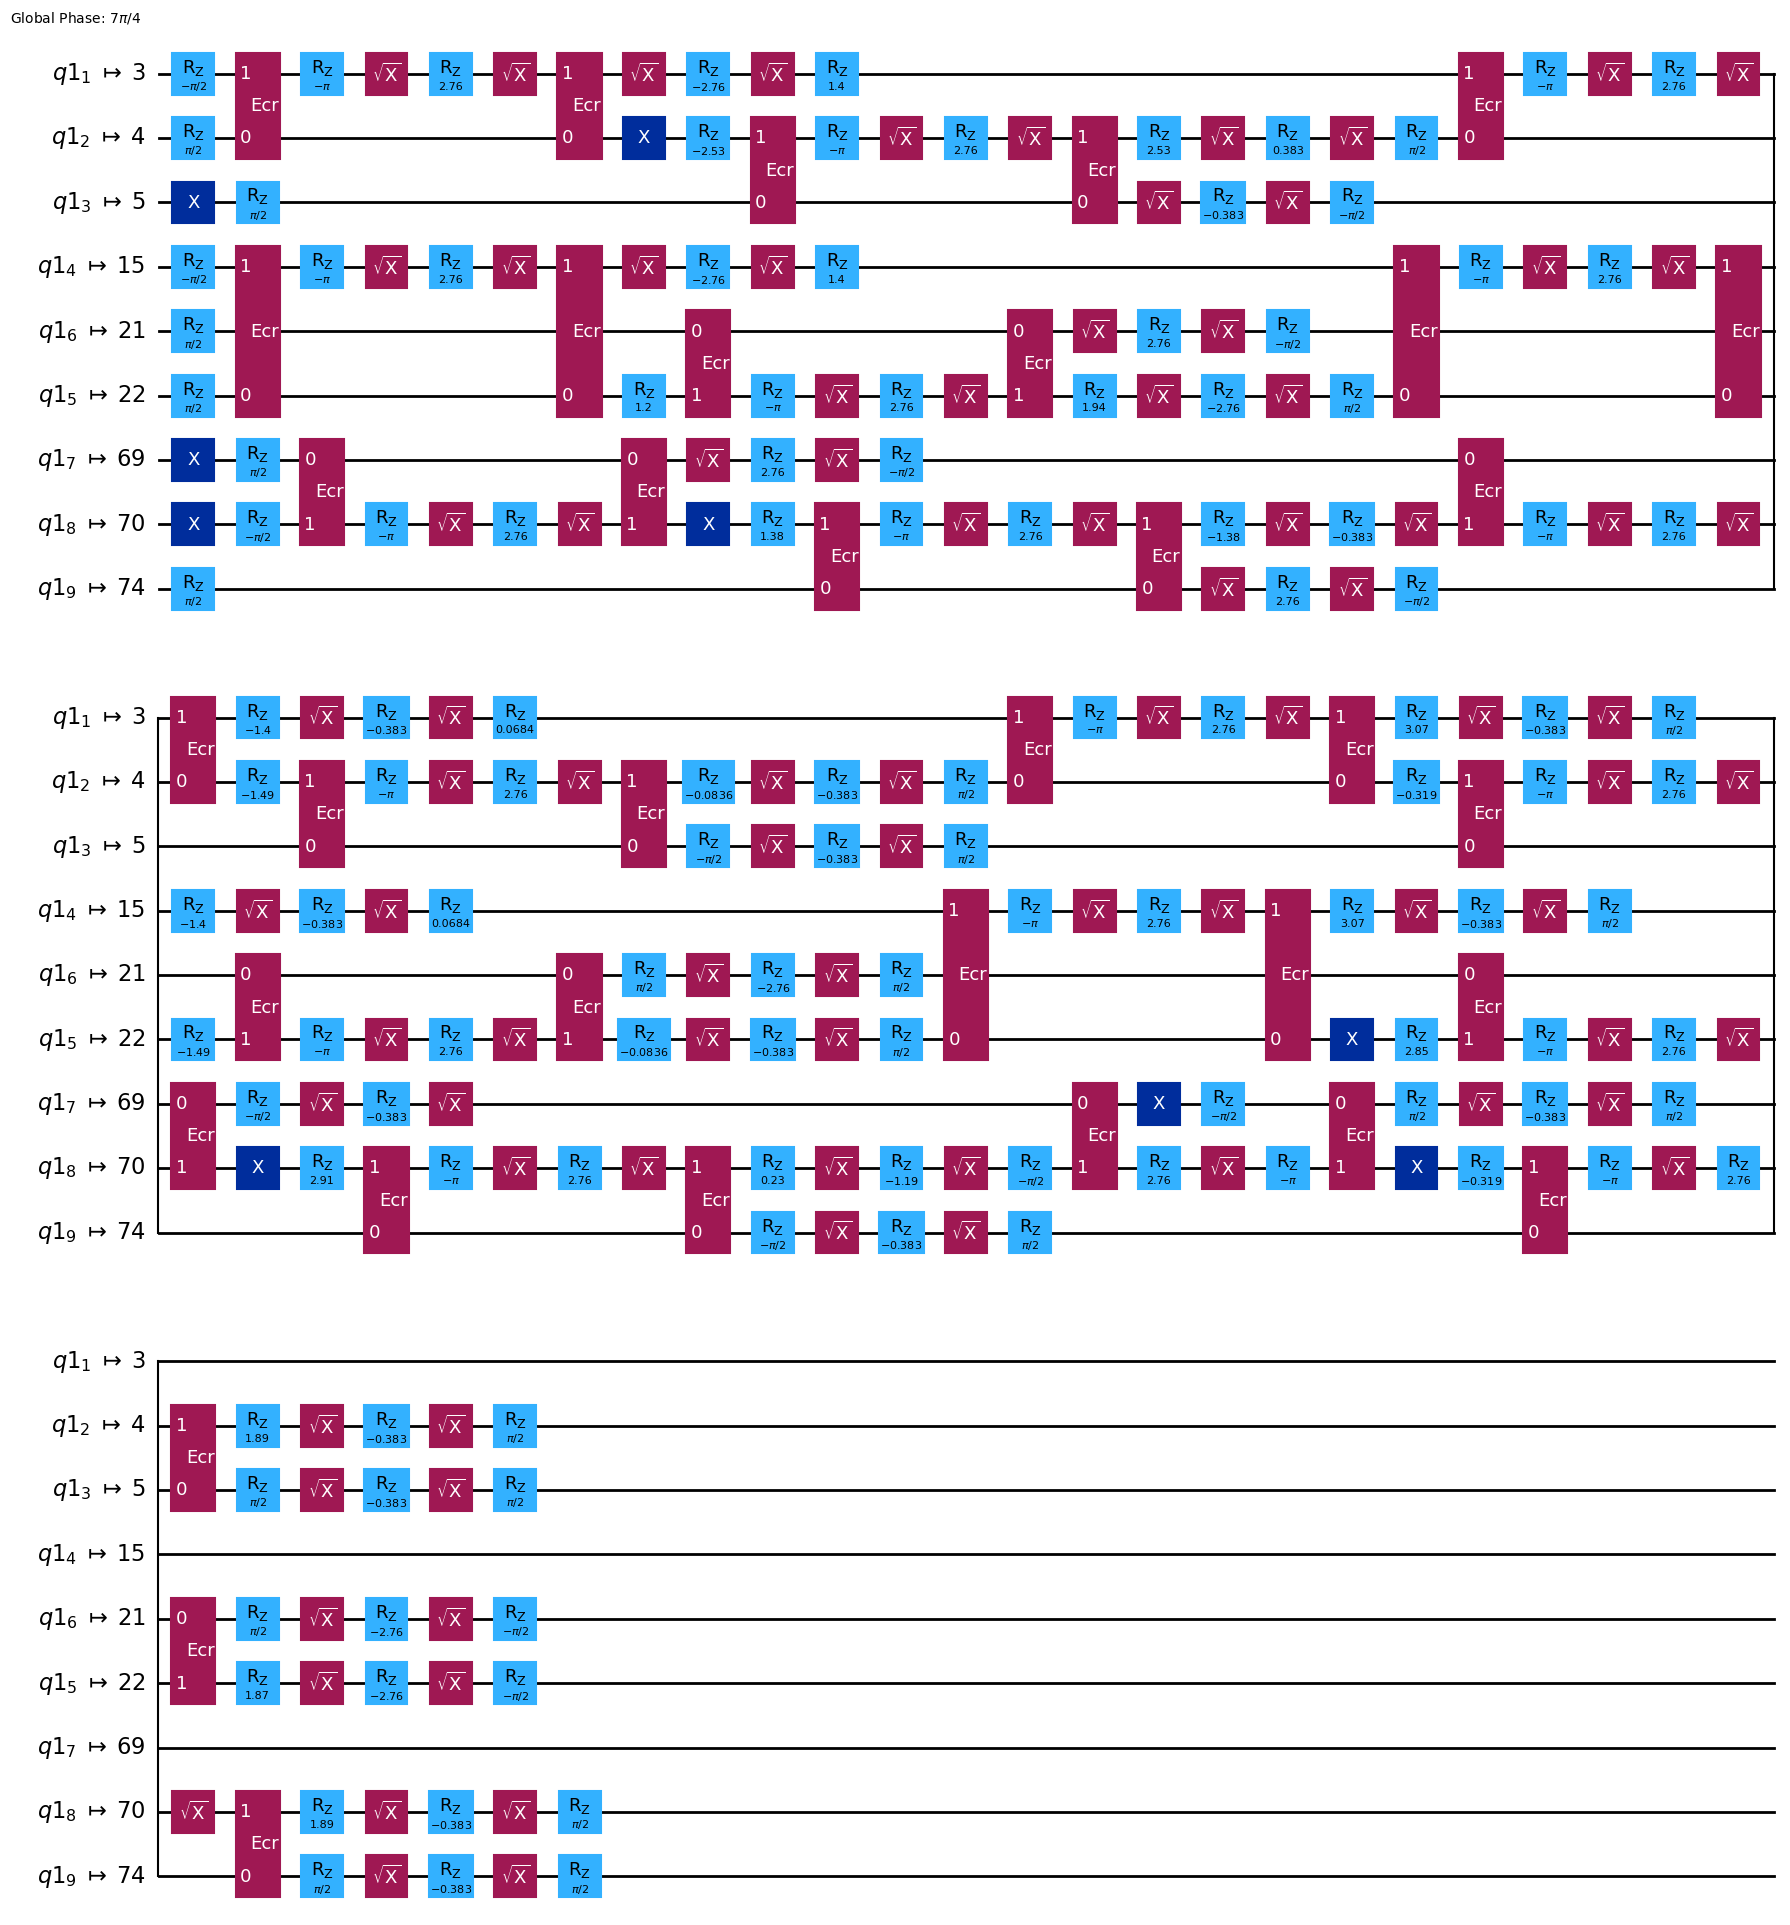

0.9406784674946875


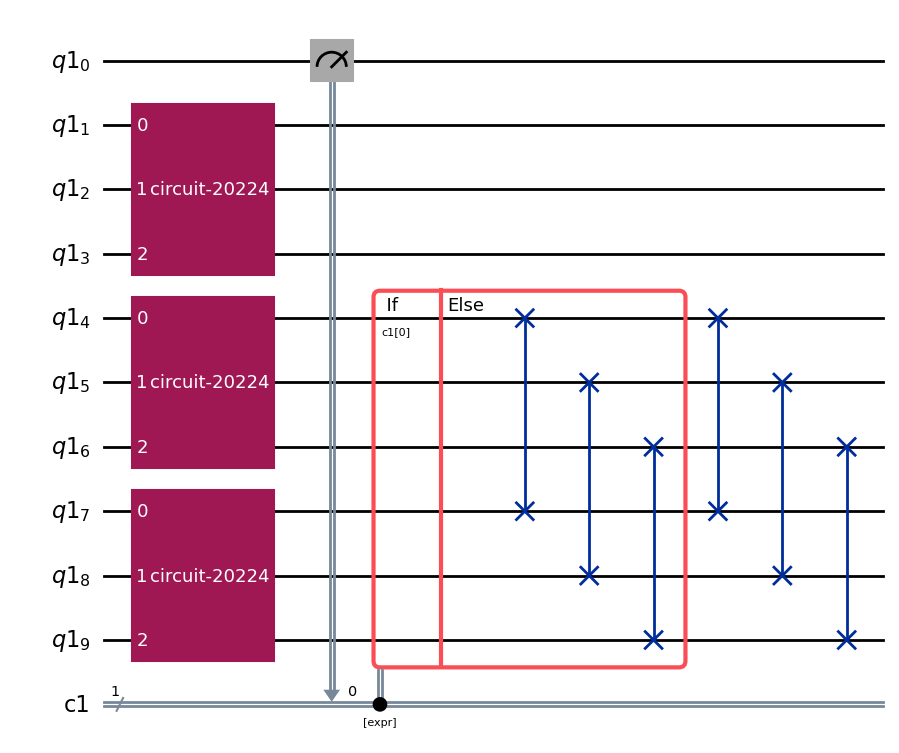

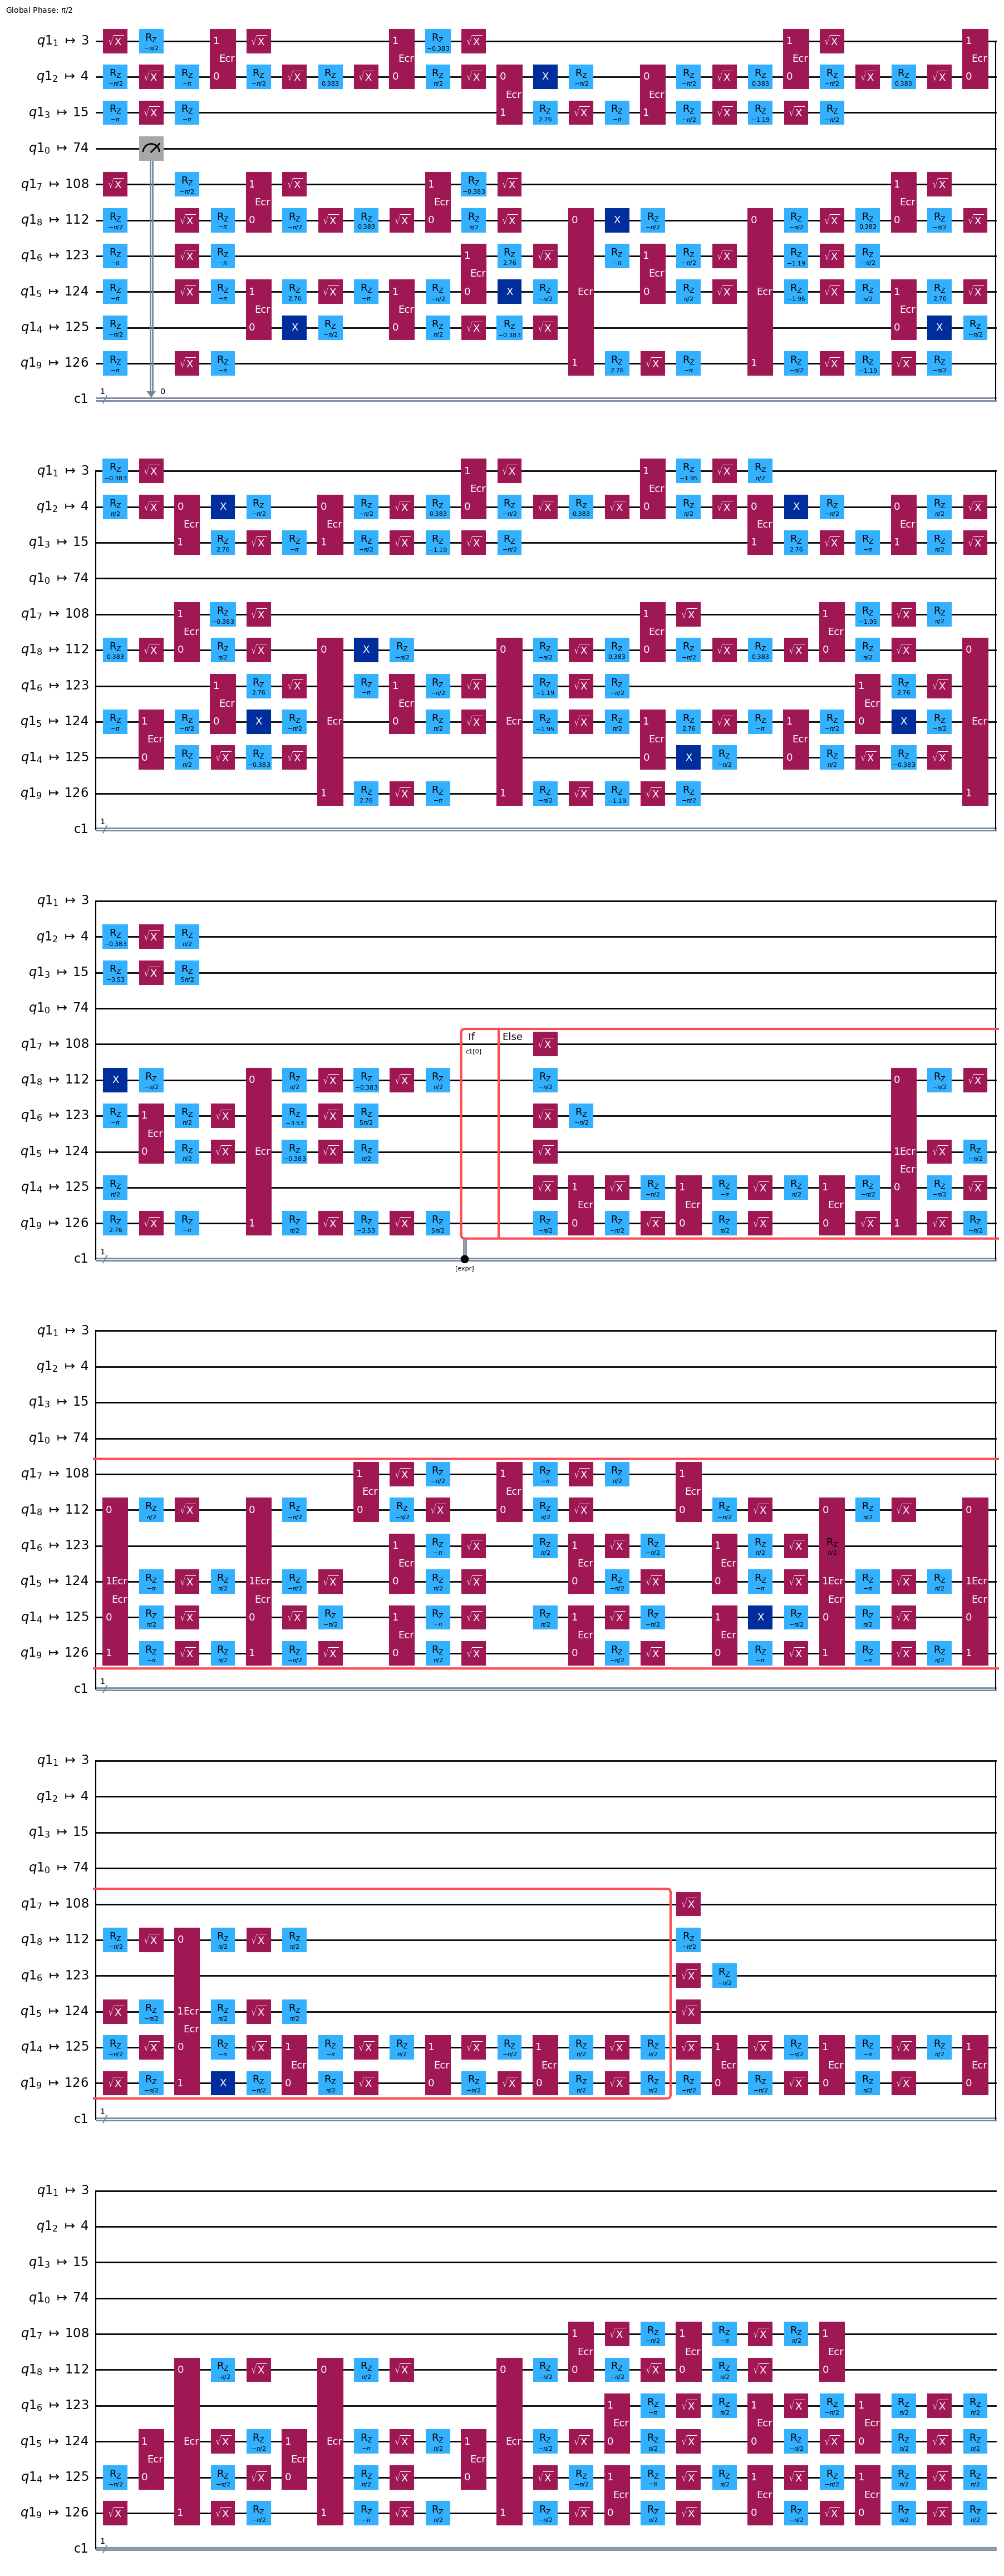

0.7325299839021868


In [4]:
estimator = EstimatorV2(mode=backend)
estimator.options.default_shots = 1024



if single_control:
    ncontrol = 1
    get_control = lambda x: 0
else:
    ncontrol = 0
    get_control = lambda x: x



dt = t / steps
cr_q0 = ClassicalRegister(ncontrol)

qc_test = QuantumCircuit(QuantumRegister(3*d+ncontrol),cr_q0)
qc_each = QuantumCircuit(d)
for _ in range(steps):
        # Apply ZZ interactions (Z_i Z_{i+1})
        for i in range(d - 1):
            qc_each.cx(i, i + 1)
            qc_each.rz(-2 * J * dt, i + 1)
            qc_each.cx(i, i + 1)

        # Apply transverse field X terms (X_i)
        for i in range(d):
            qc_each.rx(-2 * h * dt, i)

# Convert to instruction and append to registers q1, q2, q3
display(qc_each.draw('mpl'))
each_inst = qc_each.to_instruction()
for reg in [1, 2, 3]:
    qc_test.append(each_inst, [(reg-1)*d+ ncontrol + i for i in range(d)])



qc_state = qc_each.copy()
qc_state.save_statevector()
simulator = AerSimulator()
result = simulator.run(transpile(qc_state, simulator)).result()
statevec = result.get_statevector()
display(qc_test.draw('mpl'))
display(statevec.draw('latex'))
# # 3. Now run
fidelity_operator = SparsePauliOp.from_operator(statevec.to_operator())
identity_op = SparsePauliOp(["I"*d])
control_identity = SparsePauliOp(["I"*ncontrol])
full_space_fidelity_operator = fidelity_operator.tensor(identity_op).tensor(identity_op).tensor(control_identity)

observable = full_space_fidelity_operator
qc_transpiled_test = transpile(qc_test, backend=backend)
layout_test = qc_transpiled_test.layout
display(qc_transpiled_test.draw(output='mpl',idle_wires=False))
observable_test= full_space_fidelity_operator.apply_layout(layout_test)
jobtest = estimator.run([(qc_transpiled_test, observable_test, None)]).result()

fidelitytest = jobtest[0].data.evs
print(fidelitytest)

# # for i in range(ncontrol):
# #     qc_test.h(i)

# # for i in range(d):
# #     qc_test.cswap(0,i+ncontrol,i+ncontrol+d)
# # for i in range(ncontrol):
# #     qc_test.h(i)

for i in range(ncontrol): #Measure the control registers and find z
    qc_test.measure(i, cr_q0[i])
    if i==0:
        parity_control = qiskit_classical.expr.lift(cr_q0[i])
    else:
        parity_control = qiskit_classical.expr.bit_xor(parity_control, cr_q0[i])

with qc_test.if_test(parity_control) as _else:
#--------Z=1
    # for k in range(d):
    #     qc_test.swap(k+d+ncontrol, k+2*d+ncontrol) #Swap q2 with q3
    pass
with _else:
    #---------Z = 0
    # qc.x(d+1) # Good test to make sure it's working
    for k in range(d):
        qc_test.swap(k+d+ncontrol, k+2*d+ncontrol) #Swap q2 with q3
for k in range(d):
    qc_test.swap(k+d+ncontrol, k+2*d+ncontrol) #Swap q2 with q3
# for k in range(d):
#     qc_test.swap(k+d+ncontrol, k+2*d+ncontrol) #Swap q2 with q3
display(qc_test.draw('mpl'))
qc_transpiled_test = transpile(qc_test, backend=backend, optimization_level=1)
display(qc_transpiled_test.draw(output='mpl',idle_wires=False))
layout_test = qc_transpiled_test.layout
observable_test= full_space_fidelity_operator.apply_layout(layout_test)
jobtest = estimator.run([(qc_transpiled_test, observable_test, None)]).result()

fidelitytest = jobtest[0].data.evs
print(fidelitytest)




### Test Providers Limits

In [107]:

from qiskit_ibm_runtime.fake_provider import (
    FakeNairobiV2, FakeJakartaV2, FakeKolkataV2, FakeGuadalupeV2, FakeTorontoV2,
    FakeMontrealV2, FakeManilaV2, FakeLagosV2,FakeSherbrooke,FakeBrisbane
)

fake_backends = [
    FakeNairobiV2(), FakeJakartaV2(), FakeKolkataV2(),
    FakeGuadalupeV2(), FakeTorontoV2(), FakeMontrealV2(),
    FakeManilaV2(), FakeLagosV2(),FakeBrisbane(),FakeSherbrooke()
]
from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler.exceptions import TranspilerError

compatible_backends = []

def test_circuit(qc):
  for backend in fake_backends:
      print(f"Trying {backend.name}...")
      if qc.num_qubits > backend.num_qubits:
          print(f"❌ Too many qubits for {backend.name}")
          continue
      try:
          pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
          transpiled_qc= pm.run(qc)  # QPA is your circuit
          print(f"✅ Compatible with {backend.name}")
      except Exception as e:
          print(f"❌ Incompatible with {backend.name}: {e}")


Manually setting the operations

In [28]:
d=3

cr_q0 = ClassicalRegister(1,name='control')
qr_all = QuantumRegister(3*d+1)

# Initialize quantum circuit with classical registers
qc = QuantumCircuit(qr_all, cr_q0)
qc.h(0)#q0_firstqbit = |0>+|1>/sqrt2
# Apply the first CSWAP gate controlled by q0, targeting q1 and q2
for k in range(d):
    qc.cswap(0, k+1, k+d+1)#|+>_k x SYM12_k + |->_k x AntiSYM12_k /norm

# Apply the second Hadamard gate to q0
qc.h(0)
# Measure qubits 0 to d-1 into classical bits 0 to d-1
qc.measure(0, cr_q0[0])
parity_control = qiskit_classical.expr.lift(cr_q0[0])
with qc.if_test(parity_control) as _else:
    #--------Z=1
    pass
with _else:
#---------Z = 0
# qc.x(d+1) # Good test to make sure it's working
    for k in range(d):
        #   q1 = k+2*d
        #   q2 = k+3*d
        #   qc.cx(q1, q2)
        #   qc.cx(q2, q1)
        #   qc.cx(q1, q2)
            qc.swap(k+d+1, k+2*d+1) #Swap q2 with q3

qc.reset(0)
qc.h(0)
for k in range(d):
    qc.cswap(0, k+1, k+d+1)#|+>_k x SYM12_k + |->_k x AntiSYM12_k /norm
qc.h(0)
qc.measure(0, cr_q0[0])
parity_control = qiskit_classical.expr.lift(cr_q0[0])
with qc.if_test(parity_control) as _else:
    #--------Z=1
    pass
with _else:
#---------Z = 0
# qc.x(d+1) # Good test to make sure it's working
    for k in range(d):
        #   q1 = k+2*d
        #   q2 = k+3*d
        #   qc.cx(q1, q2)
        #   qc.cx(q2, q1)
        #   qc.cx(q1, q2)
            qc.swap(k+d+1, k+2*d+1) #Swap q2 with q3

# transpiled_qc.draw('mpl')
test_circuit(qc)
qc.draw('mpl')


NameError: name 'test_circuit' is not defined

Using the function

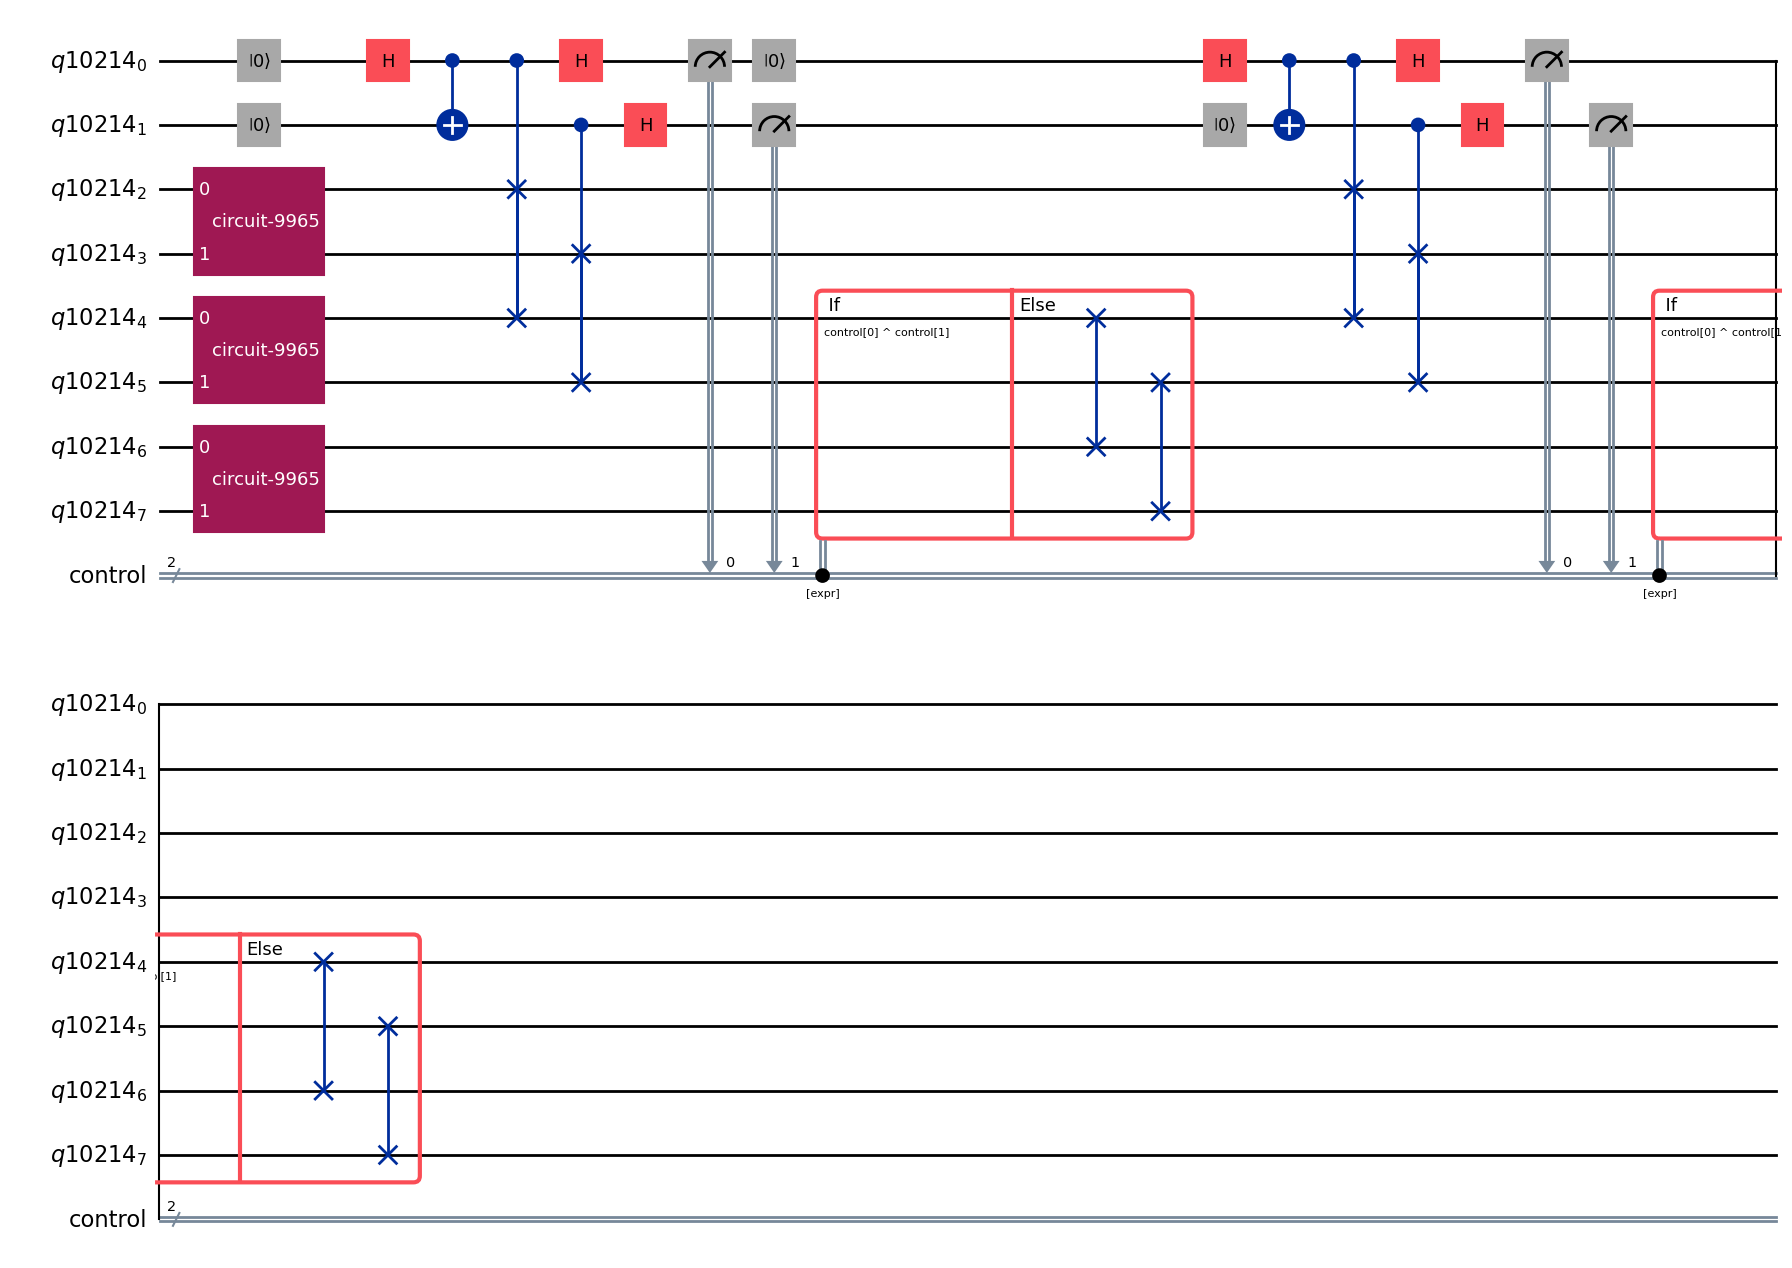

In [117]:
def get_QPA_test_single_control(d, N, ising_circuit):
    #FUNCTION TO GET QPA CIRCUIT

    cr_q0 = ClassicalRegister(d,name='control')
    qr_all = QuantumRegister(3*d+1)

    # Initialize quantum circuit with classical registers
    qcSWAP = QuantumCircuit(qr_all, cr_q0)  # Extra qubit and classical bit for parity check
    
    # qc = ising_circuit.apply_ising_to_registers(qcSWAP) #Apply trotterized Ising circuit, 1)
    qc=qcSWAP
    ising = ising_circuit.get_trotterized_ising_circuit()
    # Convert to instruction and append to registers q1, q2, q3
    ising_inst = ising.to_instruction()
    for reg in [1, 2, 3]:
        qc.append(ising_inst, [(reg-1) * d + i+1 for i in range(d)])
    
    def recursive(N,qc):
      qc.reset(0)
      qc.h(0)#q0_firstqbit = |0>+|1>/sqrt2

      # Apply the first CSWAP gate controlled by q0, targeting q1 and q2
      for k in range(d):
        qc.cswap(0, k+1, k+d+1)#|+>_k x SYM12_k + |->_k x AntiSYM12_k /norm

      # Apply the second Hadamard gate to q0
      qc.h(0)
      # Measure qubits 0 to d-1 into classical bits 0 to d-1

      qc.measure(0, cr_q0[0])
      parity_control = qiskit_classical.expr.lift(cr_q0[0])

      with qc.if_test(parity_control) as _else:
        #--------Z=1
        pass
      with _else:
        #---------Z = 0
        # qc.x(d+1) # Good test to make sure it's working
        for k in range(d):
          qc.swap(k+d+1, k+2*d+1) #Swap q2 with q3
      if N!=1:
        qc = recursive(N-1,qc) #Do it again unless it was the final iteration of the SWAPNET
      return qc
    if N!=0:
      qc = recursive(N,qcSWAP)
    else:
      qc = qcSWAP
    return qc

def get_QPA_test_d_controls(d, N, ising_circuit):
#FUNCTION TO GET QPA CIRCUIT

    cr_q0 = ClassicalRegister(d,name='control')
    qr_all = QuantumRegister(4*d)

    # Initialize quantum circuit with classical registers
    qcSWAP = QuantumCircuit(qr_all, cr_q0)  # Extra qubit and classical bit for parity check
    
    qc = ising_circuit.apply_ising_to_registers(qcSWAP) #Apply trotterized Ising circuit, 1)
    
    def recursive(N,qc):
      for k in range(d):
        qc.reset(k)
      qc.h(0)#q0_firstqbit = |0>+|1>/sqrt2
      for k in range(d-1):
        qc.cx(0,1+k)#q0 = |0000...> + |1111...>/sqrt2
      # Apply the first CSWAP gate controlled by q0, targeting q1 and q2
      for k in range(d):
        qc.cswap(0+k, k+d, k+2*d)#|+>_k x SYM12_k + |->_k x AntiSYM12_k /norm

      # Apply the second Hadamard gate to q0
      for k in range(d):
        qc.h(k) #|0> x SYM12 + |1> x AntiSYM12 /norm
      # Measure qubits 0 to d-1 into classical bits 0 to d-1




      for i in range(d): #Measure the control registers and find z
          qc.measure(i, cr_q0[i])
          if i==0:
            parity_control = qiskit_classical.expr.lift(cr_q0[i])
          else:
            parity_control = qiskit_classical.expr.bit_xor(parity_control, cr_q0[i])

      with qc.if_test(parity_control) as _else:
        #--------Z=1
        pass
      with _else:
        #---------Z = 0
        # qc.x(d+1) # Good test to make sure it's working
        for k in range(d):
          q1 = k+2*d
          q2 = k+3*d
          qc.swap(k+2*d, k+3*d) #Swap q2 with q3
      if N!=1:
        qc = recursive(N-1,qc) #Do it again unless it was the final iteration of the SWAPNET
      return qc
    if N!=0:
      qc = recursive(N,qcSWAP)
    else:
      qc = qcSWAP
    # Gets Measure register q3 and save in the classical register
    # for i in range(d):
    #     qc.measure(3*d+i, cr_q0[i]) 
    return qc



d=2
Nqpa=2

t=5.0
J=1
h=1
steps = 5
ising_test = ising_class(d, steps, t, J, h)
QPA_test_single = get_QPA_test_single_control(d,Nqpa,ising_test) 
QPA_test_multiple = get_QPA_test_d_controls(d,Nqpa,ising_test)
# qc = QPA_test_single
qc = QPA_test_multiple

backed = FakeBrisbane()
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
transpiled_qc= pm.run(qc)  # QPA is your circuit
# transpiled_qc.draw('mpl')
qc.draw('mpl')
